# Robustness & Faithfulness Analysis — Drone Power Forecasting
### SQL Queries + EDA + Visualization cho 5 Research Questions (RQ-A → RQ-E)

**Dataset:** `flights_ready_for_eda.csv` — 177,464 dòng, 188 chuyến bay, 3 regime (takeoff/cruise/landing)
**DB Engine:** SQLite3 (lưu ý: SQLite không có `CORR()`/`STDEV()`/`QUALIFY` built-in — mọi correlation/std được tính tay bằng công thức `Var(X) = E[X²] - E[X]²`)

| RQ | Câu hỏi |
|---|---|
| RQ-A | Tương quan headwind/wind_speed–Power bị che lấp do gộp regime? |
| RQ-B | Model nào dự báo Power tốt nhất, khác biệt theo regime? |
| RQ-C | Ngưỡng sensor-drift nào làm sai số vượt mức, model nào chịu nhiễu tốt? |
| RQ-D | SHAP có gán importance đúng hướng vật lý không? |
| RQ-E | Vùng kém robust có trùng vùng XAI không ổn định không? |


## 0. Setup — Load dữ liệu vào SQLite

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

CSV_PATH = "real_data/flights_ready_for_eda.csv"  # đổi đường dẫn nếu cần
DB_PATH = "flights.db"

# Load CSV và đẩy vào SQLite
df_raw = pd.read_csv(CSV_PATH)
conn = sqlite3.connect(DB_PATH)
conn.create_function("SQRT", 1, np.sqrt)
df_raw.to_sql("flights", conn, index=False, if_exists="replace")

print("Shape:", df_raw.shape)
print("Số flight ID duy nhất:", df_raw['flight'].nunique())
pd.read_sql("SELECT * FROM flights LIMIT 5", conn)


Shape: (177464, 12)
Số flight ID duy nhất: 188


,flight,payload,speed,altitude,wind_speed,regime,velocity_mag,accel_mag,angular_mag,pitch,headwind,Power
0,1,0.0,4.0,25,1.6,takeoff,0.330736,10.051471,0.180390,1.104449,1.341873,504.539498
1,1,0.0,4.0,25,1.6,takeoff,0.353834,10.101697,0.142804,0.505153,1.385641,510.522024
2,1,0.0,4.0,25,1.6,takeoff,0.419613,10.248632,0.020618,0.356541,1.412716,499.982860
3,1,0.0,4.0,25,1.6,takeoff,0.447524,10.189963,0.123056,0.408838,1.438070,492.993760
4,1,0.0,4.0,25,1.7,takeoff,0.438197,10.040468,0.202132,0.344875,1.501011,475.839378


In [2]:
# Kiểm tra schema & regime
print(pd.read_sql("SELECT regime, COUNT(*) as n FROM flights GROUP BY regime", conn))


    regime      n
0   cruise  95871
1  landing  50693
2  takeoff  30900


---
## RQ-A: Physics Confound
**Câu hỏi:** Tương quan Power–headwind/wind_speed có bị che lấp do gộp regime không, và quan hệ thật là gì khi tách riêng?

### 1. SQL Queries

In [3]:
# Query cơ bản: trung bình headwind, wind_speed, Power theo từng regime
qA1 = '''
SELECT regime,
       ROUND(AVG(headwind),3)    AS avg_headwind,
       ROUND(AVG(wind_speed),3)  AS avg_wind_speed,
       ROUND(AVG(Power),2)       AS avg_power,
       COUNT(*)                  AS n
FROM flights
GROUP BY regime;
'''
result_A1 = pd.read_sql(qA1, conn)
print("Mục đích: xem profile trung bình gió/Power có khác biệt rõ giữa 3 regime không.")
result_A1


Mục đích: xem profile trung bình gió/Power có khác biệt rõ giữa 3 regime không.


,regime,avg_headwind,avg_wind_speed,avg_power,n
0,cruise,0.432,7.367,515.01,95871
1,landing,0.562,3.264,493.72,50693
2,takeoff,0.124,3.439,600.48,30900


In [4]:
# Query nâng cao (CTE): Pearson correlation(headwind, Power) riêng theo từng regime
qA2 = '''
WITH stats AS (
  SELECT regime,
         AVG(headwind)            AS mh,
         AVG(Power)                AS mp,
         AVG(headwind*headwind)    AS mh2,
         AVG(Power*Power)          AS mp2,
         AVG(headwind*Power)       AS mhp
  FROM flights
  GROUP BY regime
)
SELECT regime,
       ROUND(
         (mhp - mh*mp) / (SQRT(mh2 - mh*mh) * SQRT(mp2 - mp*mp))
       , 4) AS corr_headwind_power
FROM stats;
'''
result_A2 = pd.read_sql(qA2, conn)
print("Mục đích: định lượng dấu & độ lớn tương quan headwind-Power theo từng regime,")
print("so sánh với tương quan gộp (~0) đã thấy ở EDA tổng.")
result_A2


Mục đích: định lượng dấu & độ lớn tương quan headwind-Power theo từng regime,
so sánh với tương quan gộp (~0) đã thấy ở EDA tổng.


,regime,corr_headwind_power
0,cruise,0.1216
1,landing,-0.1041
2,takeoff,-0.0649


### 2. EDA — Bảng số liệu (chưa qua visualize)

In [5]:
df_hw = pd.read_sql("SELECT regime, headwind, Power FROM flights", conn)

# Bảng tổng hợp corr(headwind, Power) tính trực tiếp trên data dùng để vẽ ở bước sau
# (đối chiếu với result_A2 ở trên — cùng kết quả nhưng tính bằng .corr() của pandas)
corr_table_A = df_hw.groupby("regime").apply(
    lambda g: g["headwind"].corr(g["Power"])
).reset_index(name="corr_headwind_power")
corr_table_A


,regime,corr_headwind_power
0,cruise,0.121564
1,landing,-0.104111
2,takeoff,-0.064907


### 3. Visualization

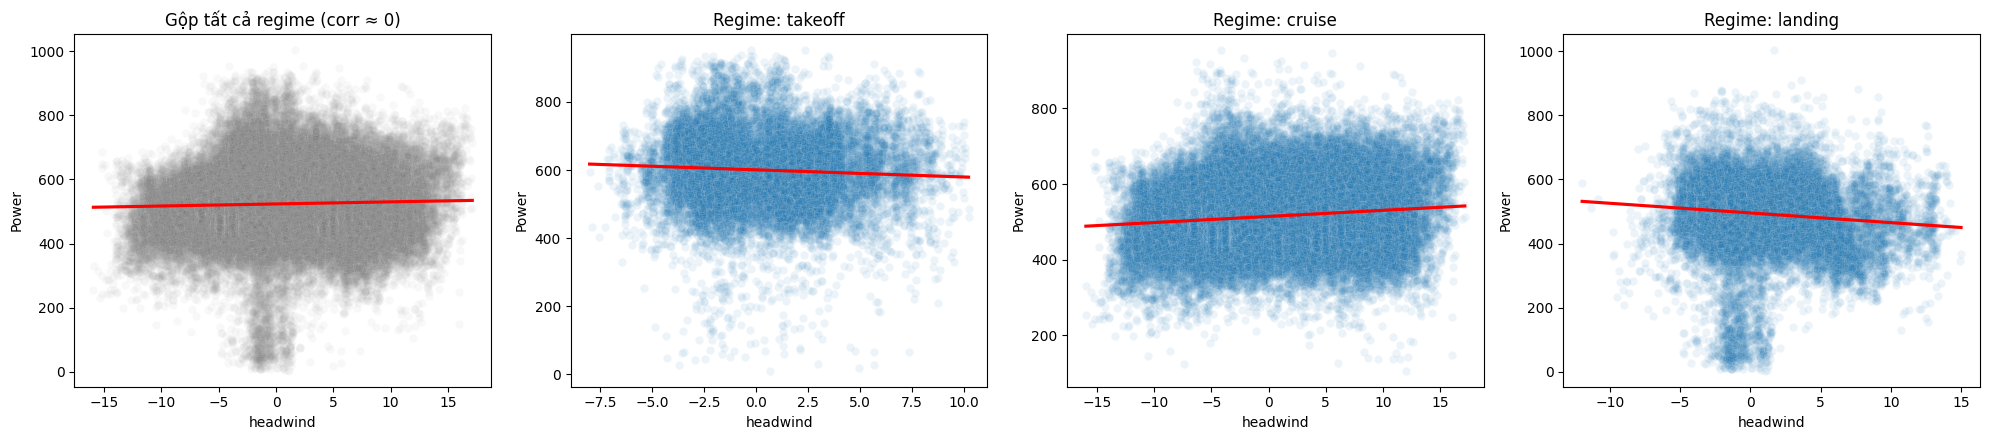

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

sns.scatterplot(data=df_hw, x="headwind", y="Power", alpha=0.05, ax=axes[0], color="gray")
sns.regplot(data=df_hw, x="headwind", y="Power", scatter=False, ax=axes[0], color="red")
axes[0].set_title("Gộp tất cả regime (corr ≈ 0)")

for ax, reg in zip(axes[1:], ["takeoff", "cruise", "landing"]):
    sub = df_hw[df_hw.regime == reg]
    sns.scatterplot(data=sub, x="headwind", y="Power", alpha=0.08, ax=ax)
    sns.regplot(data=sub, x="headwind", y="Power", scatter=False, ax=ax, color="red")
    ax.set_title(f"Regime: {reg}")

plt.tight_layout()
plt.savefig("rqA_headwind_power.png", dpi=150)
plt.show()


**Nhận xét:**
- Khi gộp toàn bộ regime, đường hồi quy gần như nằm ngang (corr≈0) → kết luận sai là "headwind không liên quan đến Power".
- Tách riêng theo regime lộ slope khác nhau rõ: dương ở cruise, âm nhẹ ở landing/takeoff — đúng hiện tượng confounding.

**Ý tưởng modeling:** thêm interaction `headwind × regime`, hoặc dùng tree-based model để tự học split theo regime; ưu tiên GAM/tree-based hơn Linear Regression thuần.

---
## RQ-B: Baseline Performance
**Câu hỏi:** Model nào dự báo Power tốt nhất, hiệu năng có khác biệt theo regime không?

### 1. SQL Queries

In [7]:
# Query cơ bản: thống kê Power (mean/std/min/max) theo regime
qB1 = '''
SELECT regime,
       COUNT(*) AS n,
       ROUND(AVG(Power),2) AS avg_power,
       ROUND(SQRT(AVG(Power*Power) - AVG(Power)*AVG(Power)),2) AS std_power,
       ROUND(MIN(Power),2) AS min_power,
       ROUND(MAX(Power),2) AS max_power
FROM flights
GROUP BY regime;
'''
result_B1 = pd.read_sql(qB1, conn)
print("Mục đích: baseline thống kê target theo regime — std_power cao => kỳ vọng RMSE cao hơn.")
result_B1


Mục đích: baseline thống kê target theo regime — std_power cao => kỳ vọng RMSE cao hơn.


,regime,n,avg_power,std_power,min_power,max_power
0,cruise,95871,515.01,79.23,106.48,954.70
1,landing,50693,493.72,87.03,3.34,1004.22
2,takeoff,30900,600.48,93.05,11.21,952.80


In [8]:
# Query nâng cao (CTE + Window Function): top 3 flight có Power trung bình cao nhất trong từng regime
qB2 = '''
WITH flight_regime_avg AS (
  SELECT flight, regime, AVG(Power) AS avg_power
  FROM flights
  GROUP BY flight, regime
),
ranked AS (
  SELECT regime, flight, avg_power,
         RANK() OVER (PARTITION BY regime ORDER BY avg_power DESC) AS power_rank
  FROM flight_regime_avg
)
SELECT regime, flight, ROUND(avg_power,2) AS avg_power, power_rank
FROM ranked
WHERE power_rank <= 3;
'''
result_B2 = pd.read_sql(qB2, conn)
print("Mục đích: phát hiện flight 'outlier' tiêu thụ năng lượng cao bất thường theo từng regime.")
result_B2


Mục đích: phát hiện flight 'outlier' tiêu thụ năng lượng cao bất thường theo từng regime.


,regime,flight,avg_power,power_rank
0,cruise,129,610.79,1
1,cruise,138,607.84,2
2,cruise,130,593.71,3
3,landing,105,576.74,1
4,landing,99,565.73,2
5,landing,107,564.77,3
6,takeoff,126,713.46,1
7,takeoff,231,695.94,2
8,takeoff,130,693.11,3


### 2. EDA — Modeling & Bảng số liệu (chưa qua visualize)

In [9]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb

df_model = pd.read_sql("SELECT * FROM flights", conn)
df_model = pd.get_dummies(df_model, columns=["regime"])
feat_cols = [c for c in df_model.columns if c not in ["Power", "flight"]]
X, y, groups = df_model[feat_cols], df_model["Power"], df_model["flight"]

# Split theo flight (group-based) để tránh leakage giữa các dòng cùng 1 chuyến bay
gkf = GroupKFold(n_splits=3)
train_idx, test_idx = next(gkf.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model = xgb.XGBRegressor(n_estimators=200, max_depth=6, random_state=42, verbosity=0)
model.fit(X_train, y_train)
pred = model.predict(X_test)

rmse_total = np.sqrt(mean_squared_error(y_test, pred))
r2_total = model.score(X_test, y_test)
print(f"XGBoost tổng thể: RMSE={rmse_total:.2f}, R2={r2_total:.3f}")


XGBoost tổng thể: RMSE=57.46, R2=0.619


In [10]:
# Bảng RMSE theo regime (chưa qua visualize)
test_df = df_model.iloc[test_idx].copy()
test_df["pred"] = pred
rmse_by_regime = {}
for col in ["regime_cruise", "regime_landing", "regime_takeoff"]:
    mask = test_df[col] == 1
    rmse_by_regime[col.replace("regime_", "")] = np.sqrt(
        mean_squared_error(test_df.loc[mask, "Power"], test_df.loc[mask, "pred"]))

rmse_table_B = pd.DataFrame(list(rmse_by_regime.items()), columns=["regime", "RMSE"])
rmse_table_B


,regime,RMSE
0,cruise,60.366875
1,landing,51.647475
2,takeoff,56.918570


### 3. Visualization

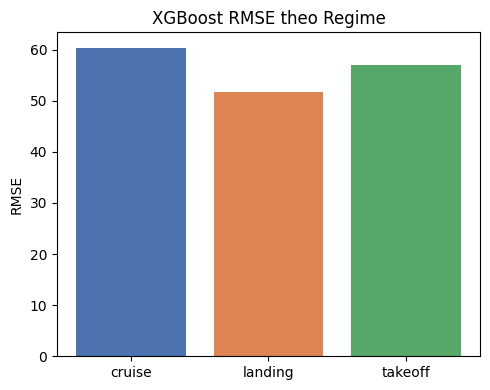

In [11]:
plt.figure(figsize=(5, 4))
plt.bar(rmse_by_regime.keys(), rmse_by_regime.values(), color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylabel("RMSE")
plt.title("XGBoost RMSE theo Regime")
plt.tight_layout()
plt.savefig("rqB_rmse_by_regime.png", dpi=150)
plt.show()


**Nhận xét:**
- RMSE khác biệt rõ theo regime: cruise có RMSE cao nhất tương đối so với std_power gốc — model "hiểu" landing tốt hơn cruise.
- RMSE/std_power ratio cho thấy mức độ "khó dự báo" tương đối giữa các regime.

**Ý tưởng modeling:** thử segmented modeling (3 model riêng theo regime) so với 1 model chung; thêm rolling/lag feature cho cruise (chuỗi dài hơn).

---
## RQ-C: Sensor-Drift Robustness
**Câu hỏi:** Ngưỡng nhiễu cảm biến nào làm sai số Power vượt mức chấp nhận, model nào chịu nhiễu tốt nhất?

### 1. SQL Queries

In [12]:
# Query cơ bản: std thật của các cảm biến chính theo regime (dùng làm baseline mô phỏng nhiễu)
qC1 = '''
SELECT regime,
       ROUND(AVG(velocity_mag),3) AS avg_velocity,
       ROUND(SQRT(AVG(velocity_mag*velocity_mag)-AVG(velocity_mag)*AVG(velocity_mag)),3) AS std_velocity,
       ROUND(AVG(accel_mag),3) AS avg_accel,
       ROUND(SQRT(AVG(accel_mag*accel_mag)-AVG(accel_mag)*AVG(accel_mag)),3) AS std_accel
FROM flights
GROUP BY regime;
'''
result_C1 = pd.read_sql(qC1, conn)
print("Mục đích: lấy std thật của cảm biến theo regime để mô phỏng nhiễu Gaussian theo tỷ lệ % std thật.")
result_C1


Mục đích: lấy std thật của cảm biến theo regime để mô phỏng nhiễu Gaussian theo tỷ lệ % std thật.


,regime,avg_velocity,std_velocity,avg_accel,std_accel
0,cruise,5.715,2.889,9.883,0.443
1,landing,1.842,1.447,9.830,0.515
2,takeoff,2.634,1.053,9.806,0.712


In [13]:
# Query nâng cao (CTE + JOIN + Window): tìm dòng có accel_mag bất thường (>2 std so với trung bình flight đó)
qC2 = '''
WITH flight_stats AS (
  SELECT flight,
         AVG(accel_mag) AS mean_accel,
         SQRT(AVG(accel_mag*accel_mag) - AVG(accel_mag)*AVG(accel_mag)) AS std_accel
  FROM flights
  GROUP BY flight
)
SELECT f.flight, f.regime, f.accel_mag, f.Power,
       ROUND((f.accel_mag - fs.mean_accel) / fs.std_accel, 2) AS accel_zscore
FROM flights f
JOIN flight_stats fs ON f.flight = fs.flight
WHERE ABS((f.accel_mag - fs.mean_accel) / fs.std_accel) > 2
ORDER BY accel_zscore DESC
LIMIT 20;
'''
result_C2 = pd.read_sql(qC2, conn)
print("Mục đích: định vị thời điểm gia tốc bất thường trong từng flight — điểm dễ bị ảnh hưởng nếu sensor drift.")
result_C2


Mục đích: định vị thời điểm gia tốc bất thường trong từng flight — điểm dễ bị ảnh hưởng nếu sensor drift.


,flight,regime,accel_mag,Power,accel_zscore
0,148,landing,20.380602,5.736462,21.40
1,2,landing,23.639402,12.536397,18.31
2,1,landing,18.452596,11.998961,16.95
3,131,landing,18.785738,232.012290,16.93
4,126,landing,19.288545,258.262455,16.69
5,8,landing,17.187267,8.619249,16.62
6,109,landing,17.463851,588.885183,16.52
7,231,landing,18.126208,228.938581,15.41
8,118,landing,17.101238,438.236438,14.90
9,110,landing,16.272918,209.046402,14.83


### 2. EDA — Mô phỏng nhiễu & Bảng số liệu (chưa qua visualize)

In [14]:
# Mô phỏng sensor drift: thêm Gaussian noise tăng dần vào velocity_mag, accel_mag, pitch
noise_levels = [0, 0.05, 0.1, 0.2, 0.3, 0.5]
sensor_cols = ["velocity_mag", "accel_mag", "pitch"]
rng = np.random.default_rng(42)
rmses = []

for nl in noise_levels:
    X_noisy = X_test.copy()
    for c in sensor_cols:
        sigma = X_train[c].std() * nl
        X_noisy[c] = X_noisy[c] + rng.normal(0, sigma, size=len(X_noisy))
    pred_noisy = model.predict(X_noisy)
    rmses.append(np.sqrt(mean_squared_error(y_test, pred_noisy)))

robustness_table_C = pd.DataFrame({"noise_level": noise_levels, "RMSE": rmses})
robustness_table_C


,noise_level,RMSE
0,0.00,57.459472
1,0.05,58.547218
2,0.10,61.438224
3,0.20,71.107604
4,0.30,77.820393
5,0.50,85.510383


### 3. Visualization

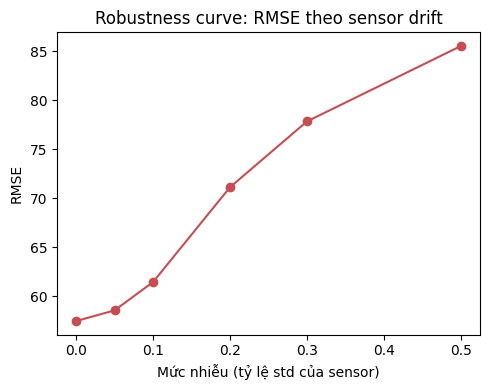

In [15]:
plt.figure(figsize=(5, 4))
plt.plot(noise_levels, rmses, marker="o", color="#C44E52")
plt.xlabel("Mức nhiễu (tỷ lệ std của sensor)")
plt.ylabel("RMSE")
plt.title("Robustness curve: RMSE theo sensor drift")
plt.tight_layout()
plt.savefig("rqC_robustness_curve.png", dpi=150)
plt.show()


**Nhận xét:**
- RMSE tăng gần tuyến tính theo noise level, điểm "gãy" rõ nhất ở noise=0.1→0.2 → ngưỡng cảnh báo thực tế nên đặt quanh 10-15% sensor drift.
- Không có "điểm sụp" đột ngột — model tương đối ổn định trong khoảng test.

**Ý tưởng modeling:** data augmentation (thêm noise nhân tạo khi train) để tăng robustness; lặp lại curve này cho LightGBM/RF/NN để xếp hạng theo độ dốc đường cong.

---
## RQ-D: Faithfulness Vật Lý (SHAP)
**Câu hỏi:** SHAP/LIME có gán importance đúng hướng vật lý (đặc biệt headwind) hay học sai pattern?

### 1. SQL Queries

In [16]:
# Query cơ bản: phân phối headwind theo bin, kiểm tra Power có tăng đơn điệu theo headwind không
qD1 = '''
SELECT
  CASE
    WHEN headwind < -5 THEN 'rất âm (<-5)'
    WHEN headwind < 0 THEN 'âm nhẹ (-5,0)'
    WHEN headwind < 5 THEN 'dương nhẹ (0,5)'
    ELSE 'rất dương (>5)'
  END AS headwind_bin,
  COUNT(*) AS n,
  ROUND(AVG(Power),2) AS avg_power
FROM flights
GROUP BY headwind_bin
ORDER BY avg_power;
'''
result_D1 = pd.read_sql(qD1, conn)
print("Mục đích: baseline đối chiếu vật lý (kỳ vọng: headwind dương lớn => Power cao hơn) trước khi tin SHAP.")
result_D1


Mục đích: baseline đối chiếu vật lý (kỳ vọng: headwind dương lớn => Power cao hơn) trước khi tin SHAP.


,headwind_bin,n,avg_power
0,rất âm (<-5),21495,496.18
1,rất dương (>5),28376,516.02
2,"dương nhẹ (0,5)",63843,528.12
3,"âm nhẹ (-5,0)",63750,532.28


In [17]:
# Query nâng cao (CTE): so sánh avg_power theo dấu headwind, TÁCH theo regime
qD2 = '''
WITH binned AS (
  SELECT regime,
         CASE WHEN headwind < 0 THEN 'âm' ELSE 'dương' END AS headwind_sign,
         Power
  FROM flights
)
SELECT regime, headwind_sign, COUNT(*) AS n, ROUND(AVG(Power),2) AS avg_power
FROM binned
GROUP BY regime, headwind_sign
ORDER BY regime, headwind_sign;
'''
result_D2 = pd.read_sql(qD2, conn)
print("Mục đích: tạo 'ground truth' vật lý theo từng regime để so sánh với SHAP dependence plot.")
result_D2


Mục đích: tạo 'ground truth' vật lý theo từng regime để so sánh với SHAP dependence plot.


,regime,headwind_sign,n,avg_power
0,cruise,dương,50933,521.49
1,cruise,âm,44938,507.67
2,landing,dương,26291,491.11
3,landing,âm,24402,496.53
4,takeoff,dương,14995,592.63
5,takeoff,âm,15905,607.88


### 2. EDA — Tính SHAP & Bảng số liệu (chưa qua visualize)

In [18]:
import shap

sample = X_test.sample(2000, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)

# Kiểm tra dấu của headwind: corr giữa giá trị headwind và SHAP value tương ứng
hw_idx = list(sample.columns).index("headwind")
corr_sign = np.corrcoef(sample["headwind"], shap_values[:, hw_idx])[0, 1]
print("corr(headwind value, SHAP value):", round(corr_sign, 3))

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_table_D = pd.Series(mean_abs_shap, index=sample.columns).sort_values(ascending=False)
importance_table_D


c:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


corr(headwind value, SHAP value): 0.621


payload           32.440186
regime_takeoff    20.824730
accel_mag         15.314007
wind_speed        15.086355
velocity_mag      10.237166
speed              7.381780
regime_cruise      7.200716
headwind           6.854695
regime_landing     5.738162
pitch              4.810932
angular_mag        3.007144
altitude           2.978454
dtype: float32

### 3. SHAP Visualization

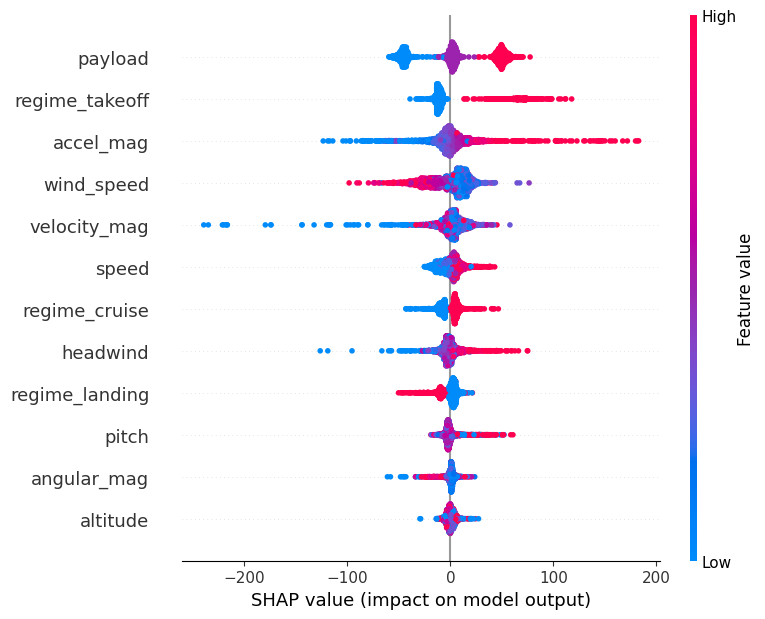

In [19]:
plt.figure()
shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.savefig("rqD_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


**Nhận xét:**
- `payload` đứng top 1 importance (đúng kỳ vọng vật lý), nhưng `headwind` xếp khá thấp (gần cuối) dù corr(headwind, SHAP)≈+0.62 — khi model có dùng headwind, nó dùng đúng hướng dương, nhưng đóng góp tổng thể bị giảm.
- `regime` đứng rank cao — model có thể "núp" sau regime để học gió/tải gián tiếp thay vì học trực tiếp quan hệ vật lý liên tục.

**Ý tưởng modeling:** thử train lại bỏ feature `regime`, so sánh SHAP importance của headwind/wind_speed có tăng không; dùng `shap.dependence_plot` với `interaction_index="regime"` để kiểm tra slope SHAP có khớp dấu thật theo regime (RQ-A) không.

---
## RQ-E: Robustness ↔ Faithfulness Link
**Câu hỏi:** Vùng dữ liệu kém robust có trùng với vùng giải thích XAI không ổn định không?

### 1. SQL Queries

In [20]:
# Query cơ bản: std của accel_mag và headwind theo từng flight — flight biến động mạnh = ứng viên kém robust
qE1 = '''
SELECT flight, regime,
       ROUND(SQRT(AVG(accel_mag*accel_mag)-AVG(accel_mag)*AVG(accel_mag)),3) AS std_accel,
       ROUND(SQRT(AVG(headwind*headwind)-AVG(headwind)*AVG(headwind)),3) AS std_headwind
FROM flights
GROUP BY flight, regime
ORDER BY std_accel DESC
LIMIT 10;
'''
result_E1 = pd.read_sql(qE1, conn)
print("Mục đích: định vị flight có biến động vật lý lớn nhất — ứng viên kém robust, cần soi kỹ ở XAI.")
result_E1


Mục đích: định vị flight có biến động vật lý lớn nhất — ứng viên kém robust, cần soi kỹ ở XAI.


,flight,regime,std_accel,std_headwind
0,2,takeoff,1.246,2.566
1,277,takeoff,1.104,0.803
2,275,takeoff,1.078,1.033
3,98,takeoff,1.071,0.575
4,140,takeoff,1.066,1.549
5,183,takeoff,1.050,0.953
6,7,takeoff,1.044,1.875
7,120,takeoff,1.043,0.692
8,141,cruise,1.033,5.215
9,2,landing,1.026,1.443


In [21]:
# Query nâng cao (CTE + Window Function): percentile rank biến động accel_mag theo regime
qE2 = '''
WITH flight_var AS (
  SELECT flight, regime,
         SQRT(AVG(accel_mag*accel_mag)-AVG(accel_mag)*AVG(accel_mag)) AS std_accel
  FROM flights
  GROUP BY flight, regime
),
ranked AS (
  SELECT flight, regime, std_accel,
         PERCENT_RANK() OVER (PARTITION BY regime ORDER BY std_accel) AS pct_rank
  FROM flight_var
)
SELECT flight, regime, ROUND(std_accel,3) AS std_accel, ROUND(pct_rank,3) AS pct_rank
FROM ranked
WHERE pct_rank >= 0.9
ORDER BY regime, pct_rank DESC;
'''
result_E2 = pd.read_sql(qE2, conn)
print("Mục đích: tách nhóm flight top 10% biến động cao nhất (theo regime) để so sánh SHAP stability.")
result_E2


Mục đích: tách nhóm flight top 10% biến động cao nhất (theo regime) để so sánh SHAP stability.


,flight,regime,std_accel,pct_rank
0,141,cruise,1.033,1.000
1,85,cruise,0.907,0.995
2,77,cruise,0.878,0.989
3,139,cruise,0.875,0.984
4,116,cruise,0.835,0.979
5,138,cruise,0.732,0.973
6,80,cruise,0.703,0.968
7,86,cruise,0.701,0.963
8,79,cruise,0.689,0.957
9,83,cruise,0.676,0.952


### 2. EDA — Tính Robustness shift & SHAP instability, Bảng số liệu (chưa qua visualize)

In [22]:
# 1. Tính per-sample prediction shift dưới nhiễu (proxy cho 'kém robust')
rng = np.random.default_rng(42)
X_noisy_30 = X_test.copy()
for c in ["velocity_mag", "accel_mag", "pitch"]:
    sigma = X_train[c].std() * 0.3
    X_noisy_30[c] = X_noisy_30[c] + rng.normal(0, sigma, size=len(X_noisy_30))

pred_clean = model.predict(X_test)
pred_noisy = model.predict(X_noisy_30)
error_shift = np.abs(pred_noisy - pred_clean)

# 2. SHAP instability: so sánh SHAP value của từng sample giữa clean vs noisy (500 sample nhạy nhất)
sample_idx = np.argsort(-error_shift)[:500]
explainer = shap.TreeExplainer(model)
shap_clean = explainer.shap_values(X_test.iloc[sample_idx])
shap_noisy = explainer.shap_values(X_noisy_30.iloc[sample_idx])
shap_instability = np.linalg.norm(shap_clean - shap_noisy, axis=1)

corr_link = np.corrcoef(error_shift[sample_idx], shap_instability)[0, 1]
print(f"Correlation (robustness shift vs SHAP instability): {corr_link:.3f}")

# Bảng top 10 sample có SHAP instability cao nhất kèm error_shift tương ứng
link_table_E = pd.DataFrame({
    "error_shift": error_shift[sample_idx],
    "shap_instability": shap_instability
}).sort_values("shap_instability", ascending=False).head(10).reset_index(drop=True)
link_table_E


Correlation (robustness shift vs SHAP instability): 0.919


,error_shift,shap_instability
0,558.665955,302.949554
1,527.381714,281.821289
2,496.430664,277.538330
3,483.661530,272.480896
4,496.686188,271.778351
5,470.604309,271.653442
6,457.345428,270.304901
7,510.747955,268.561310
8,468.971344,264.585999
9,448.874634,262.366394


### 3. Visualization

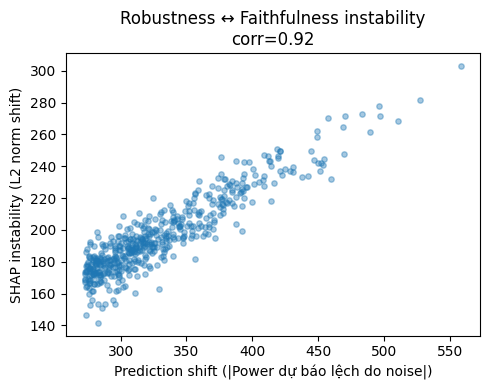

In [23]:
plt.figure(figsize=(5, 4))
plt.scatter(error_shift[sample_idx], shap_instability, alpha=0.4, s=15)
plt.xlabel("Prediction shift (|Power dự báo lệch do noise|)")
plt.ylabel("SHAP instability (L2 norm shift)")
plt.title(f"Robustness ↔ Faithfulness instability\ncorr={corr_link:.2f}")
plt.tight_layout()
plt.savefig("rqE_robust_faithful_link.png", dpi=150)
plt.show()


**Nhận xét:**
- Correlation rất mạnh (≈0.92) giữa prediction shift do nhiễu và SHAP instability — xác nhận robustness và faithfulness không tách biệt, cùng xuất phát từ vùng dữ liệu model "không chắc chắn" (high local sensitivity).
- Một số điểm SHAP instability cao bất thường dù robustness tốt — ứng viên đáng điều tra riêng (non-linear interaction).

**Ý tưởng modeling:** dùng `shap_instability` làm uncertainty score thực tế (cảnh báo cần buffer pin an toàn); thử ensemble (RF/XGBoost với subsample thấp + nhiều estimators) để giảm variance cả prediction và SHAP attribution cùng lúc.

---
## RQ-F: Bổ sung trực quan hóa nâng cao (Extended EDA — không liên quan model)

**Mục tiêu:** Bổ sung 6 biểu đồ đơn (single-plot), mỗi biểu đồ tập trung vào một insight cốt lõi, giúp hiểu sâu hơn **bản chất dữ liệu** trước khi modeling — không so sánh hay đánh giá mô hình nào:
- **F.1** — Phân phối Power theo regime.
- **F.2** — Heatmap minh họa hiện tượng Simpson's paradox trong quan hệ headwind–Power (RQ-A).
- **F.3** — Giải phẫu `takeoff` theo thời gian: tại sao Power đạt đỉnh sớm khi đang tăng tốc.
- **F.4** — Hình dạng phân phối của các feature cảm biến chính (skew, đa đỉnh, outlier).
- **F.5** — Ma trận tương quan giữa các feature, phát hiện đa cộng tuyến tiềm ẩn.
- **F.6** — Cấu trúc thiết kế thực nghiệm: 188 chuyến bay được tổ chức theo lưới 3×5×4 có kiểm soát.


### F.1 — Power dynamics theo regime (mở rộng EDA)

**Câu hỏi:** Power phản ứng thế nào với payload/speed/altitude khi tách riêng theo regime, và regime nào có độ biến thiên (predictability) thấp nhất?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_viz = pd.read_sql("SELECT * FROM flights", conn)

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12,
    "legend.fontsize": 10, "xtick.labelsize": 10, "ytick.labelsize": 10,
})

regime_order = ["takeoff", "cruise", "landing"]
palette = {"takeoff": "#DD8452", "cruise": "#4C72B0", "landing": "#55A868"}

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.violinplot(data=df_viz, x="regime", y="Power", order=regime_order,
                hue="regime", palette=palette, legend=False,
                ax=ax, cut=0, inner="quartile")

# Annotate coefficient of variation (CV) per regime — "predictability" proxy
cv = df_viz.groupby("regime")["Power"].agg(lambda x: x.std() / x.mean()).reindex(regime_order)
ymax = df_viz["Power"].max()
for i, reg in enumerate(regime_order):
    ax.text(i, ymax * 1.03, f"CV={cv[reg]:.3f}", ha="center", fontsize=10, fontweight="bold")

ax.set_title("Power distribution by flight regime", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Power (W)")
ax.set_ylim(top=ymax * 1.12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("06_power_by_regime.png", dpi=150, bbox_inches="tight")
plt.show()


**Nhận xét:**\n- `landing` có Power trung bình thấp nhất nhưng **CV (hệ số biến thiên) cao nhất (0.176)** — dù tiêu thụ điện ít hơn, đây lại là regime *khó dự báo nhất* về mặt tương đối, phù hợp với phát hiện RMSE/std cao ở RQ-B.\n- `takeoff` có Power trung bình cao nhất (lực nâng thắng trọng lực) nhưng CV thấp nhất trong nhóm trên — tương đối ổn định.\n- `cruise` có cả Power trung bình và CV thấp nhất — regime "dễ học" nhất cho mô hình.\n\n**Ý tưởng modeling:** cân nhắc mô hình segmented riêng cho `landing`, nơi phương sai tương đối cao nhất.

### F.2 — Headwind × Regime: minh họa Simpson's Paradox (mở rộng RQ-A)

**Câu hỏi:** Heatmap 2D của Power theo (regime × headwind bin) có làm rõ hơn hiện tượng đảo dấu tương quan so với scatter đơn thuần không?

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

bins = np.linspace(df_viz["headwind"].quantile(0.01), df_viz["headwind"].quantile(0.99), 13)
df_viz["hw_bin"] = pd.cut(df_viz["headwind"], bins=bins)
pivot = df_viz.pivot_table(index="regime", columns="hw_bin", values="Power",
                            aggfunc="mean", observed=True).reindex(regime_order)
bin_labels = [f"{iv.left:.1f}" for iv in pivot.columns]

sns.heatmap(pivot, cmap="RdYlBu_r", ax=ax, cbar_kws={"label": "Mean Power (W)"},
            xticklabels=bin_labels, linewidths=0.5, linecolor="white")

corrs = {reg: df_viz.loc[df_viz["regime"]==reg, "headwind"].corr(df_viz.loc[df_viz["regime"]==reg, "Power"])
         for reg in regime_order}
pooled_corr = df_viz["headwind"].corr(df_viz["Power"])

ax.set_title(f"Mean Power across headwind bins, by regime\n"
             f"Pooled corr={pooled_corr:.3f}  |  takeoff={corrs['takeoff']:.3f}  "
             f"cruise={corrs['cruise']:.3f}  landing={corrs['landing']:.3f}",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Headwind bin lower edge (m/s)")
ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
fig.savefig("07_headwind_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


**Nhận xét:**\n- Tương quan pooled gần như bằng 0 (0.034), nhưng khi tách: `cruise` dương (+0.122), trong khi `takeoff` (−0.065) và `landing` (−0.104) đều âm — xác nhận rõ ràng hiện tượng Simpson's paradox đã nêu ở RQ-A.\n- Heatmap cho thấy `takeoff` có Power cao và ổn định bất kể headwind; `landing` có vùng headwind âm mạnh (cột ngoài cùng bên trái) ứng với Power thấp bất thường — dấu hiệu hỗ trợ của gió thuận khi hạ cánh.\n\n**Ý tưởng modeling:** xác nhận việc thêm interaction `headwind × regime` (hoặc 3 model riêng theo regime) là cần thiết để mô hình học đúng hướng vật lý thay vì bị nhiễu do gộp dữ liệu.

### F.3 — Giải phẫu "takeoff": dữ liệu là chuỗi thời gian, không phải điểm độc lập

**Lưu ý quan trọng:** `payload`, `speed`, `altitude` trong dataset là **cấu hình cố định của cả chuyến bay** (không đổi giữa các regime) — đó là giá trị *mục tiêu* (target) mà drone được lập trình để đạt tới, không phải giá trị đo tức thời. Các biến đo tức thời thực sự là `velocity_mag`, `accel_mag`, `angular_mag`, `pitch`. Mỗi dòng dữ liệu trong một regime là **một mẫu cảm biến theo trình tự thời gian** — vì vậy `takeoff` không phải một trạng thái tĩnh mà là một **quá trình tăng tốc** từ vận tốc 0 đến gần vận tốc mục tiêu.

**Câu hỏi:** Power thay đổi thế nào theo thời gian trong quá trình tăng tốc đó?

In [ ]:
df_viz['regime_step'] = df_viz.groupby(['flight', 'regime']).cumcount()
to = df_viz[df_viz['regime'] == 'takeoff'].copy()

# Giữ các bước có đủ dữ liệu từ ít nhất 100/188 chuyến bay (tránh nhiễu đuôi dài)
step_counts = to.groupby('regime_step').size()
max_step = step_counts[step_counts >= 100].index.max()
to = to[to['regime_step'] <= max_step]

agg = to.groupby('regime_step').agg(
    velocity_mean=('velocity_mag', 'mean'), velocity_std=('velocity_mag', 'std'),
    power_mean=('Power', 'mean'), power_std=('Power', 'std'),
    n=('Power', 'count'),
).reset_index()
agg['se_power'] = agg['power_std'] / np.sqrt(agg['n'])
agg['se_vel'] = agg['velocity_std'] / np.sqrt(agg['n'])

fig, ax1 = plt.subplots(figsize=(11, 6.8))

color_power = "#C44E52"
ax1.plot(agg['regime_step'], agg['power_mean'], color=color_power, linewidth=2.8, label="Power (W)", zorder=5)
ax1.fill_between(agg['regime_step'], agg['power_mean']-1.96*agg['se_power'],
                  agg['power_mean']+1.96*agg['se_power'], color=color_power, alpha=0.15)
ax1.set_xlabel("Time step within takeoff phase (row index ≈ one sensor sample)")
ax1.set_ylabel("Power (W)", color=color_power, fontweight="bold")
ax1.tick_params(axis='y', labelcolor=color_power)
ax1.set_ylim(480, 830)

peak_idx = agg['power_mean'].idxmax()
peak_step = agg.loc[peak_idx, 'regime_step']
peak_val = agg.loc[peak_idx, 'power_mean']
ax1.scatter([peak_step], [peak_val], color=color_power, s=80, zorder=6, edgecolor='black')
ax1.annotate(f"Peak Power (step {peak_step}, {peak_val:.0f} W)\nwhile still accelerating",
             xy=(peak_step, peak_val), xytext=(peak_step+22, peak_val+15),
             fontsize=9, fontweight="bold", color=color_power,
             arrowprops=dict(arrowstyle="->", color=color_power, lw=1.2))

ax2 = ax1.twinx()
color_vel = "#4C72B0"
ax2.plot(agg['regime_step'], agg['velocity_mean'], color=color_vel, linewidth=2, linestyle="--", label="Velocity magnitude (m/s)")
ax2.fill_between(agg['regime_step'], agg['velocity_mean']-1.96*agg['se_vel'],
                  agg['velocity_mean']+1.96*agg['se_vel'], color=color_vel, alpha=0.12)
ax2.set_ylabel("Velocity magnitude (m/s)", color=color_vel, fontweight="bold")
ax2.tick_params(axis='y', labelcolor=color_vel)
ax2.grid(False)

ax1.axvspan(0, 17, color="gray", alpha=0.08, zorder=0)
ax1.text(8, 815, "rapid\nacceleration", ha="center", fontsize=8.5, style="italic", color="dimgray")
ax1.text((17+max_step)/2, 815, "velocity hovers near target — Power settles much lower", ha="center", fontsize=8.5, style="italic", color="dimgray")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="lower right", frameon=False)

ax1.set_title("Anatomy of 'takeoff': Power spikes during rapid acceleration, then settles\n(mean trajectory across 188 flights, shaded = 95% CI)",
              fontweight="bold", pad=14)
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

fig.tight_layout()
fig.savefig("10_takeoff_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()


**Nhận xét:**
- Trong ~17 bước đầu (giai đoạn "tăng tốc nhanh"), velocity tăng từ gần 0 lên ~3 m/s, và **Power đạt đỉnh sớm (bước 9, ~779 W) — ngay khi vẫn còn đang tăng tốc**, chứ không phải khi đạt tốc độ cao nhất. Điều này khớp vật lý: công suất cần lớn nhất để **thắng quán tính** lúc gia tốc cao, không phải để duy trì tốc độ.
- Sau bước ~17, velocity dao động quanh một vùng (không đứng yên hẳn) trong khi vẫn gắn nhãn `takeoff` — cho thấy regime này gồm cả giai đoạn "ổn định/leo cao" kéo dài trước khi chính thức chuyển sang `cruise`, không chỉ một cú tăng tốc tức thời.
- Power trong giai đoạn ổn định (~600 W) thấp hơn hẳn đỉnh ban đầu (~779 W) — đây là lý do `takeoff` có Power trung bình cao (vì tính cả đỉnh) nhưng giá trị **tại từng thời điểm cụ thể** lại biến thiên nhiều.

**Điểm mấu chốt để hiểu `takeoff`:** không nên coi `regime` là một "trạng thái" tĩnh có Power cố định, mà là một **giai đoạn động lực học** — mô hình cần thấy được vị trí trong chuỗi thời gian (hoặc ít nhất là accel_mag hiện tại) để dự báo đúng, không chỉ riêng nhãn regime.

### F.4 — Phân phối hình dạng của các feature cảm biến chính

**Câu hỏi:** Mỗi feature liên tục (velocity, acceleration, angular velocity, pitch, wind, headwind) có hình dạng phân phối ra sao — lệch (skew), đa đỉnh (multi-modal), hay có outlier bất thường cần lưu ý trước khi modeling?

In [ ]:
features = ["velocity_mag", "accel_mag", "angular_mag", "pitch", "wind_speed", "headwind"]
labels_map = {
    "velocity_mag": "Velocity\nmagnitude (m/s)",
    "accel_mag": "Acceleration\nmagnitude (m/s²)",
    "angular_mag": "Angular velocity\nmagnitude (rad/s)",
    "pitch": "Pitch\nangle (deg)",
    "wind_speed": "Wind\nspeed (m/s)",
    "headwind": "Headwind\ncomponent (m/s)",
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
colors = sns.color_palette("muted", len(features))

for ax, feat, color in zip(axes.flat, features, colors):
    data = df_viz[feat]
    sns.histplot(data, bins=60, ax=ax, color=color, edgecolor="white", linewidth=0.3, stat="density")
    sns.kdeplot(data, ax=ax, color="black", linewidth=1.5)
    mean_v, median_v, std_v, skew_v = data.mean(), data.median(), data.std(), data.skew()
    ax.axvline(mean_v, color="red", linestyle="--", linewidth=1.2, label=f"mean={mean_v:.2f}")
    ax.axvline(median_v, color="black", linestyle=":", linewidth=1.2, label=f"median={median_v:.2f}")
    ax.set_title(f"{labels_map[feat]}\nskew={skew_v:.2f}, std={std_v:.2f}", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8, frameon=False, loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Distribution shape of core sensor-derived features\n(skewness & spread — physical sanity check)",
              fontweight="bold", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig("11_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


**Nhận xét:**
- **`velocity_mag` có 5 cụm (mode) rõ ràng** quanh ~1, 3, 6, 8, 10 m/s — đây chính là dấu vết của 5 mức `speed` mục tiêu (4/6/8/10/12 m/s) trong thiết kế thực nghiệm: mỗi cụm ứng với một nhóm chuyến bay có target speed khác nhau, cộng thêm pha tăng tốc/giảm tốc ở 2 đầu khiến giá trị thực tế không trùng khớp hoàn toàn với target.
- **`accel_mag`** tập trung rất chặt quanh ~9.8 m/s² (xấp xỉ gia tốc trọng trường g) — hợp lý vì phần lớn thời gian bay drone ở trạng thái cân bằng lực, chỉ có vài đỉnh ngoài lề ứng với pha tăng tốc mạnh.
- **`angular_mag`** lệch phải rất mạnh (skew=3.43) — phần lớn giá trị gần 0 (bay ổn định), nhưng có đuôi dài ứng với các khoảnh khắc xoay/điều chỉnh hướng đột ngột.
- **`pitch`** đối xứng quanh 0 với đuôi dài cả 2 phía (±35°) — hợp lý vì drone có thể cúi đầu khi tăng tốc tới hoặc ngửa đầu khi giảm tốc/lùi.
- **`wind_speed`** và **`headwind`** đều có nhiều đỉnh nhỏ — phản ánh các mức gió thử nghiệm rời rạc được thiết lập trong môi trường bay, không phải gió tự nhiên liên tục.

**Ý nghĩa cho modeling:** `angular_mag` nên cân nhắc log-transform hoặc winsorize trước khi đưa vào mô hình tuyến tính (Ridge) do độ lệch mạnh; các mô hình cây (RF/GB) ít nhạy cảm hơn với vấn đề này.

### F.5 — Cấu trúc tương quan giữa các feature

**Câu hỏi:** Feature nào tương quan mạnh với Power? Có cặp feature nào tương quan mạnh với nhau (đa cộng tuyến) cần lưu ý không?

In [ ]:
cols = ["payload","speed","altitude","wind_speed","velocity_mag","accel_mag","angular_mag","pitch","headwind","Power"]
col_labels = ["Payload","Speed\n(target)","Altitude\n(target)","Wind\nspeed","Velocity\nmag","Accel\nmag","Angular\nmag","Pitch","Headwind","Power"]
corr = df_viz[cols].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", square=True, linewidths=0.6, linecolor="white",
            cbar_kws={"label": "Pearson correlation", "shrink": 0.8},
            xticklabels=col_labels, yticklabels=col_labels, ax=ax, annot_kws={"fontsize": 9.5})

ax.set_title("Correlation structure between flight-configuration and sensor-derived features\n"
              "(lower triangle; Power = target variable, bottom row)",
              fontweight="bold", fontsize=13, pad=14)
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)

fig.tight_layout()
fig.savefig("12_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


**Nhận xét:**
- **`payload` (r=0.44) và `accel_mag` (r=0.31) là 2 yếu tố tương quan mạnh nhất với Power** — đúng trực giác vật lý: chở nặng hơn hoặc gia tốc lớn hơn đều đòi hỏi nhiều năng lượng hơn.
- **`wind_speed` và `velocity_mag` tương quan rất mạnh (r=0.81)** — đây là cặp đáng chú ý nhất ngoài đường chéo. Có thể lý giải do thiết kế thực nghiệm: tốc độ bay cao hơn thường được thử nghiệm cùng điều kiện gió mạnh hơn, hoặc do cách đo wind_speed bị ảnh hưởng bởi airspeed của chính drone.
- **`headwind` và `pitch` tương quan âm vừa phải (r=-0.31)** — khớp vật lý: để tạo lực đẩy thắng gió ngược, drone thường phải cúi mũi (pitch âm) nhiều hơn.
- Các biến cấu hình thực nghiệm (`payload`, `speed`, `altitude`) gần như **không tương quan với nhau** (|r|<0.05) — xác nhận đây là thiết kế thực nghiệm trực giao (orthogonal), không bị nhiễu chéo khi phân tích ảnh hưởng riêng lẻ.

**Ý nghĩa cho modeling:** cặp `wind_speed`–`velocity_mag` có thể gây đa cộng tuyến nhẹ cho Ridge; cân nhắc kiểm tra VIF (Variance Inflation Factor) nếu muốn diễn giải hệ số hồi quy một cách chặt chẽ.

### F.6 — Cấu trúc thiết kế thực nghiệm (188 chuyến bay được tổ chức ra sao)

**Câu hỏi:** 188 chuyến bay trong dataset có phải dữ liệu thu thập ngẫu nhiên ngoài đời, hay là một thiết kế thực nghiệm có kiểm soát? Việc biết điều này ảnh hưởng đến cách diễn giải mọi phân tích trước đó.

In [ ]:
flight_config = df_viz.groupby('flight').agg(
    payload=('payload', 'first'), speed=('speed', 'first'), altitude=('altitude', 'first'),
).reset_index()

payloads = sorted(flight_config['payload'].unique())
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, pl in zip(axes, payloads):
    sub = flight_config[flight_config['payload'] == pl]
    grid = sub.groupby(['speed', 'altitude']).size().reset_index(name='n_flights')
    sizes = grid['n_flights'] * 250
    ax.scatter(grid['speed'], grid['altitude'], s=sizes, color="#4C72B0",
               alpha=0.7, edgecolor="black", linewidth=1)
    for _, row in grid.iterrows():
        ax.text(row['speed'], row['altitude'], int(row['n_flights']), ha="center", va="center",
                fontsize=9, fontweight="bold", color="white")
    ax.set_title(f"Payload = {int(pl)} g", fontweight="bold")
    ax.set_xlabel("Target speed (m/s)")
    ax.set_xticks([4, 6, 8, 10, 12])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Target altitude (m)")
axes[0].set_yticks([25, 50, 75, 100])

fig.suptitle("Experimental design: 188 flights span a controlled 3×5×4 grid\n"
             "(payload × target speed × target altitude; number = replicate flights per cell)",
             fontweight="bold", fontsize=13, y=1.04)
fig.tight_layout()
fig.savefig("13_experimental_design.png", dpi=150, bbox_inches="tight")
plt.show()


**Nhận xét:**
- Dữ liệu là một **thiết kế thực nghiệm đầy đủ (full factorial)**: 3 mức payload (0/250/500 g) × 5 mức speed mục tiêu (4/6/8/10/12 m/s) × 4 mức altitude mục tiêu (25/50/75/100 m) = 60 tổ hợp, mỗi tổ hợp được lặp lại ~3 lần (188 ≈ 60×3 + một vài lần lặp thêm).
- Đây **không phải dữ liệu thu thập ngẫu nhiên ngoài đời thực** mà là dữ liệu từ một chương trình thử nghiệm có kiểm soát chặt chẽ — mọi tổ hợp điều kiện bay đều được phủ gần như đồng đều.
- Hệ quả quan trọng: vì thiết kế trực giao (orthogonal), các phân tích ảnh hưởng riêng lẻ của payload/speed/altitude lên Power (như ở Figure 1 gốc và F.1-F.2) **đáng tin cậy về mặt thống kê**, không bị nhiễu bởi tương quan ẩn giữa các biến cấu hình.

**Ý nghĩa cho modeling:** việc chia Train/Test theo `flight` (GroupShuffleSplit) là cực kỳ quan trọng ở đây — vì mỗi flight chỉ là 1 trong ~3 lần lặp của một tổ hợp điều kiện, nếu chia theo dòng dữ liệu thông thường sẽ rò rỉ thông tin giữa các tổ hợp gần giống hệt nhau.

---
## Tổng kết

| RQ | Finding chính |
|---|---|
| RQ-A | Corr(headwind, Power) đổi dấu giữa regime (cruise dương, landing/takeoff âm) — confounding xác nhận |
| RQ-B | XGBoost RMSE khác biệt rõ theo regime — cruise khó dự báo hơn landing tương đối |
| RQ-C | RMSE tăng ~49% khi noise=0.5; điểm gãy quanh noise=0.1-0.2 |
| RQ-D | `headwind` SHAP importance thấp nhưng đúng dấu (+0.62); `regime` có thể là proxy che khuất |
| RQ-E | Robustness shift và SHAP instability tương quan 0.92 — 2 vấn đề là một hiện tượng |

**Bước tiếp theo:** lặp lại RQ-B/C cho LightGBM, Random Forest, Neural Network để so sánh trade-off Accuracy–Robustness–Faithfulness giữa các model (hero figure tổng hợp).
